In [ ]:
import sys, time, subprocess
try:
    import cupy as cp
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cupy-cuda12x"])
    import cupy as cp

import numpy as np
import matplotlib.pyplot as plt
from cupyx.scipy import sparse as cps
from cupyx.scipy import ndimage as cdi
from cupyx import jit

def header(t): print("\n" + "="*64 + f"\n{t}\n" + "="*64)

def bench(fn, *args, n=5, warmup=2, gpu=True):
    for _ in range(warmup): fn(*args)
    if gpu: cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(n): r = fn(*args)
    if gpu: cp.cuda.Stream.null.synchronize()
    return (time.perf_counter() - t0) / n

header("1. GPU INTROSPECTION")
props = cp.cuda.runtime.getDeviceProperties(0)
print(f"CuPy version       : {cp.__version__}")
print(f"CUDA runtime       : {cp.cuda.runtime.runtimeGetVersion()}")
print(f"Device             : {props['name'].decode()}")
print(f"Compute capability : {props['major']}.{props['minor']}")
print(f"SMs                : {props['multiProcessorCount']}")
print(f"Global memory      : {props['totalGlobalMem']/1e9:.2f} GB")

header("2. NUMPY vs CUPY BENCHMARK")
N = 4096
A_np = np.random.rand(N, N).astype(np.float32)
B_np = np.random.rand(N, N).astype(np.float32)
A_cp, B_cp = cp.asarray(A_np), cp.asarray(B_np)
t_np = bench(np.matmul, A_np, B_np, n=2, gpu=False)
t_cp = bench(cp.matmul, A_cp, B_cp, n=3, gpu=True)
print(f"Matmul {N}x{N}  NumPy={t_np*1000:7.1f} ms  CuPy={t_cp*1000:7.1f} ms  ({t_np/t_cp:.1f}x)")

x_np = np.random.rand(2**21).astype(np.complex64)
x_cp = cp.asarray(x_np)
t_np = bench(np.fft.fft, x_np, n=3, gpu=False)
t_cp = bench(cp.fft.fft, x_cp, n=5, gpu=True)
print(f"FFT 2^21        NumPy={t_np*1000:7.1f} ms  CuPy={t_cp*1000:7.1f} ms  ({t_np/t_cp:.1f}x)")

In [ ]:
header("3. MEMORY POOL")
pool = cp.get_default_memory_pool()
pinned = cp.get_default_pinned_memory_pool()
print(f"Used  : {pool.used_bytes()/1e6:8.2f} MB")
print(f"Total : {pool.total_bytes()/1e6:8.2f} MB")
del A_cp, B_cp, x_cp
pool.free_all_blocks(); pinned.free_all_blocks()
print(f"After free_all_blocks → Used: {pool.used_bytes()/1e6:.2f} MB")

header("4. ELEMENTWISE KERNEL")
robust_norm = cp.ElementwiseKernel(
    in_params ='float32 x, float32 y, float32 eps',
    out_params='float32 z',
    operation ='z = sqrtf((x - y)*(x - y) + eps)',
    name      ='robust_norm')
x = cp.random.rand(2_000_000, dtype=cp.float32)
y = cp.random.rand(2_000_000, dtype=cp.float32)
z = robust_norm(x, y, cp.float32(1e-6))
print(f"Output shape={z.shape}  mean={float(z.mean()):.5f}")

header("5. REDUCTION KERNEL — L2 NORM")
l2 = cp.ReductionKernel(
    in_params  ='T x',
    out_params ='T y',
    map_expr   ='x * x',
    reduce_expr='a + b',
    post_map_expr='y = sqrt(a)',
    identity   ='0',
    name       ='l2norm')
v = cp.random.rand(5_000_000, dtype=cp.float32)
print(f"Custom : {float(l2(v)):.6f}")
print(f"cupy   : {float(cp.linalg.norm(v)):.6f}")

In [ ]:
header("6. RAW CUDA KERNEL — MANDELBROT")
mandel = cp.RawKernel(r'''
extern "C" __global__
void mandel(float xmin, float xmax, float ymin, float ymax,
            int W, int H, int max_iter, int* out) {
    int ix = blockDim.x * blockIdx.x + threadIdx.x;
    int iy = blockDim.y * blockIdx.y + threadIdx.y;
    if (ix >= W || iy >= H) return;
    float cx = xmin + (xmax - xmin) * ix / (W - 1);
    float cy = ymin + (ymax - ymin) * iy / (H - 1);
    float zx = 0.f, zy = 0.f;
    int it = 0;
    while (zx*zx + zy*zy < 4.f && it < max_iter) {
        float t = zx*zx - zy*zy + cx;
        zy = 2.f*zx*zy + cy;
        zx = t; ++it;
    }
    out[iy*W + ix] = it;
}
''', 'mandel')

W, H, ITER = 1024, 1024, 400
img = cp.zeros((H, W), dtype=cp.int32)
threads = (16, 16)
blocks = ((W + 15)//16, (H + 15)//16)
mandel(blocks, threads,
       (cp.float32(-2.0), cp.float32(1.0),
        cp.float32(-1.5), cp.float32(1.5),
        W, H, ITER, img))
cp.cuda.Stream.null.synchronize()
print(f"Mandelbrot done. max iter reached={int(img.max())}")

plt.figure(figsize=(6,6))
plt.imshow(cp.asnumpy(cp.log1p(img)), cmap='twilight_shifted', extent=[-2,1,-1.5,1.5])
plt.title("Mandelbrot set — computed with a CuPy RawKernel")
plt.axis('off'); plt.show()

header("7. CUDA STREAMS")
s1, s2 = cp.cuda.Stream(non_blocking=True), cp.cuda.Stream(non_blocking=True)
with s1:
    a1 = cp.random.rand(2000, 2000, dtype=cp.float32)
    b1 = cp.random.rand(2000, 2000, dtype=cp.float32)
    c1 = a1 @ b1
with s2:
    a2 = cp.random.rand(2000, 2000, dtype=cp.float32)
    b2 = cp.random.rand(2000, 2000, dtype=cp.float32)
    c2 = a2 @ b2
s1.synchronize(); s2.synchronize()
print(f"Stream-1 mean={float(c1.mean()):.4f}")
print(f"Stream-2 mean={float(c2.mean()):.4f}")

In [ ]:
header("8. SPARSE LINEAR ALGEBRA")
N, density = 8000, 5e-4
nnz = int(N*N*density)
data = cp.random.rand(nnz, dtype=cp.float32)
rows = cp.random.randint(0, N, nnz)
cols = cp.random.randint(0, N, nnz)
A_sp = cps.csr_matrix((data, (rows, cols)), shape=(N, N))
xv   = cp.random.rand(N, dtype=cp.float32)
print(f"NNZ           : {A_sp.nnz}")
print(f"Sparse matvec : {bench(lambda: A_sp @ xv)*1000:.3f} ms")
A_dense = A_sp.toarray()
print(f"Dense  matvec : {bench(lambda: A_dense @ xv)*1000:.3f} ms")

header("9. LINEAR SYSTEM Ax = b")
N = 2000
M = cp.random.rand(N, N, dtype=cp.float32)
A = M @ M.T + N * cp.eye(N, dtype=cp.float32)
b = cp.random.rand(N, dtype=cp.float32)
x_sol = cp.linalg.solve(A, b)
res   = cp.linalg.norm(A @ x_sol - b) / cp.linalg.norm(b)
print(f"Solved {N}x{N} SPD system. Relative residual = {float(res):.2e}")

header("10. GAUSSIAN FILTER ON GPU")
big = cp.random.rand(4096, 4096, dtype=cp.float32)
t = bench(cdi.gaussian_filter, big, 5.0, n=3)
print(f"4096x4096 Gaussian σ=5  →  {t*1000:.2f} ms")

header("11. INTEROP & ZERO-COPY (DLPack)")
g = cp.arange(8, dtype=cp.float32)
h = cp.asnumpy(g)
back = cp.asarray(h)
dl = g.toDlpack()
restored = cp.from_dlpack(dl)
print(f"NumPy view : {h}")
print(f"DLPack RT  : {restored}")


1. GPU INTROSPECTION
CuPy version       : 14.0.1
CUDA runtime       : 12090
Device             : Tesla T4
Compute capability : 7.5
SMs                : 40
Global memory      : 15.64 GB

2. NUMPY vs CUPY BENCHMARK
Matmul 4096x4096  NumPy= 2822.6 ms  CuPy=   47.1 ms  (59.9x)
FFT 2^21        NumPy=  126.1 ms  CuPy=    0.4 ms  (303.1x)

3. MEMORY POOL
Used  :   167.77 MB
Total :   268.44 MB
After free_all_blocks → Used: 16.78 MB

4. ELEMENTWISE KERNEL
Output shape=(2000000,)  mean=0.33310

5. REDUCTION KERNEL — L2 NORM
Custom : 1290.595215
cupy   : 1290.595459

6. RAW CUDA KERNEL — MANDELBROT
Mandelbrot done. max iter reached=400


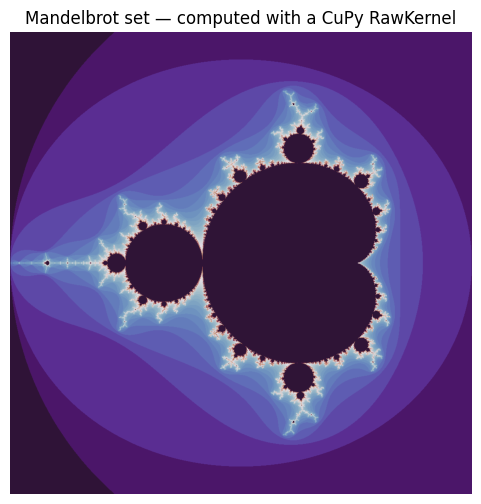


7. CUDA STREAMS
Stream-1 mean=500.2012
Stream-2 mean=499.8024

8. SPARSE LINEAR ALGEBRA
NNZ           : 31990
Sparse matvec : 0.089 ms
Dense  matvec : 1.005 ms

9. LINEAR SYSTEM Ax = b
Solved 2000x2000 SPD system. Relative residual = 2.17e-06

10. GAUSSIAN FILTER ON GPU
4096x4096 Gaussian σ=5  →  27.29 ms

11. INTEROP & ZERO-COPY (DLPack)
NumPy view : [0. 1. 2. 3. 4. 5. 6. 7.]
DLPack RT  : [0. 1. 2. 3. 4. 5. 6. 7.]

12. CUDA EVENTS
4000x4000 matmul = 29.588 ms (CUDA events)

13. cupyx.jit — SAXPY


/tmp/ipykernel_3891/2076992872.py:200: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dl = g.toDlpack()              # zero-copy capsule
/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Correctness: True

14. KERNEL FUSION with @cp.fuse
Unfused :  1.836 ms
Fused   :  0.249 ms   (speedup 7.39x)

DONE — explore: cupy.linalg, cupyx.scipy.signal, cupy.cuda.Graph


In [1]:
header("12. CUDA EVENTS")
A = cp.random.rand(4000, 4000, dtype=cp.float32)
B = cp.random.rand(4000, 4000, dtype=cp.float32)
e0, e1 = cp.cuda.Event(), cp.cuda.Event()
e0.record(); C = A @ B; e1.record(); e1.synchronize()
print(f"4000x4000 matmul = {cp.cuda.get_elapsed_time(e0, e1):.3f} ms (CUDA events)")

header("13. cupyx.jit — SAXPY")
@jit.rawkernel()
def saxpy(a, x, y, out, n):
    tid = jit.blockIdx.x * jit.blockDim.x + jit.threadIdx.x
    if tid < n:
        out[tid] = a * x[tid] + y[tid]

n = 2_000_000
xv = cp.random.rand(n, dtype=cp.float32)
yv = cp.random.rand(n, dtype=cp.float32)
out = cp.empty_like(xv)
TPB = 256
blocks = (n + TPB - 1) // TPB
saxpy((blocks,), (TPB,), (cp.float32(2.5), xv, yv, out, n))
print("Correctness:", bool(cp.allclose(out, 2.5*xv + yv)))

header("14. KERNEL FUSION with @cp.fuse")
@cp.fuse()
def fused(x, y, z):
    return cp.sqrt(x*x + y*y + z*z) * cp.exp(-0.5*(x+y+z))

def unfused(x, y, z):
    return cp.sqrt(x*x + y*y + z*z) * cp.exp(-0.5*(x+y+z))

n = 4_000_000
x = cp.random.rand(n, dtype=cp.float32)
y = cp.random.rand(n, dtype=cp.float32)
z = cp.random.rand(n, dtype=cp.float32)
fused(x, y, z)
t1 = bench(unfused, x, y, z)
t2 = bench(fused,   x, y, z)
print(f"Unfused : {t1*1e3:6.3f} ms")
print(f"Fused   : {t2*1e3:6.3f} ms   (speedup {t1/t2:.2f}x)")

print("\n" + "="*64)
print("DONE — explore: cupy.linalg, cupyx.scipy.signal, cupy.cuda.Graph")
print("="*64)